<a href="https://colab.research.google.com/github/Ashishk811/MLUP-class/blob/main/Assignment_01/MLUP_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Ashishk811/MLUP-class.git

Cloning into 'MLUP-class'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 37 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 19.09 KiB | 9.55 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file_path = r"/content/MLUP-class/Assignment_01/auto-mpg.csv"

### Load Auto MPG datasets

In [14]:
def load_auto_mpg(file_path):
    # column_names = [
    #     "mpg", "cylinders", "displacement", "horsepower",
    #     "weight", "acceleration", "model_year", "origin", "car_name"
    # ]

    try:
        df = pd.read_csv(
            file_path,
            # sep=r"\s+",
            # names=column_names,
            na_values='?',
        )

        print("\nDataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print("\nFirst 5 rows:")
        print(df.head())

        missing_count = df.isnull().sum()
        if missing_count.any():
            print("\nMissing values detected:")
            print(missing_count[missing_count > 0])
        else:
            print("\nNo missing values found.")

        return df

    except Exception as e:
        print("Error loading dataset:", e)
        return None

df = load_auto_mpg(file_path)


Dataset loaded successfully!
Shape: (398, 9)

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Missing values detected:
horsepower    6
dtype: int64


### 2. Calculate mean, median, variance, and standard deviation of MPG.

In [17]:
# converting non-numeric values to NaN and remove throse rows
df['mpg'] = pd.to_numeric(df['mpg'], errors='coerce')
df_cleaned_mpg = df.dropna(subset=['mpg'])

if not df_cleaned_mpg.empty:
    print(f"Mean of MPG: {df_cleaned_mpg['mpg'].mean()}")
    print(f"Median of MPG: {df_cleaned_mpg['mpg'].median()}")
    print(f"Variance of MPG: {df_cleaned_mpg['mpg'].var():.2f}")
    print(f"Standard Deviation of MPG: {df_cleaned_mpg['mpg'].std():.2f}")
else:
    print("\n'MPG' column is empty or contains no numeric data after cleaning, cannot calculate statistics.")

Mean of MPG: 23.514572864321607
Median of MPG: 23.0
Variance of MPG: 61.09
Standard Deviation of MPG: 7.82


### 3. Compute mean and median for horsepower and displacement.

In [22]:
print("Horsepower Mean: ", df['horsepower'].mean())
print("Horsepower Median: ", df['horsepower'].median())
print("Displacement Mean: ", df['displacement'].mean())
print("Displacement Median: ", df['displacement'].median())

Horsepower Mean:  104.46938775510205
Horsepower Median:  93.5
Displacement Mean:  193.42587939698493
Displacement Median:  148.5


### 4. Compare mean and median of displacement. Identify skewness.

In [23]:
mean_disp = df['displacement'].mean()
median_disp = df['displacement'].median()

if mean_disp > median_disp:
    print("Positively Skewed (Right Skewed)")
elif mean_disp < median_disp:
    print("Negatively Skewed (Left Skewed)")
else:
    print("Symmetric Distribution")

Positively Skewed (Right Skewed)


### 5. Identify the attribute with the highest standard deviation.

In [25]:
std_values = df.std(numeric_only=True)

highest_std_attr = std_values.idxmax()
highest_std_value = std_values.max()

print("Standard Deviation of all numeric attributes:\n")
print(std_values)

print("\nHighest Standard Deviation Attribute:", highest_std_attr)
print("Highest Standard Deviation Value:", highest_std_value)

Standard Deviation of all numeric attributes:

mpg               7.815984
cylinders         1.701004
displacement    104.269838
horsepower       38.491160
weight          846.841774
acceleration      2.757689
model year        3.697627
origin            0.802055
dtype: float64

Highest Standard Deviation Attribute: weight
Highest Standard Deviation Value: 846.841774197327


### 6. Draw a box plot for MPG and identify quartiles and outliers.

Q1: 17.5
Median: 23.0
Q3: 29.0
IQR: 11.5
Number of Outliers: 1


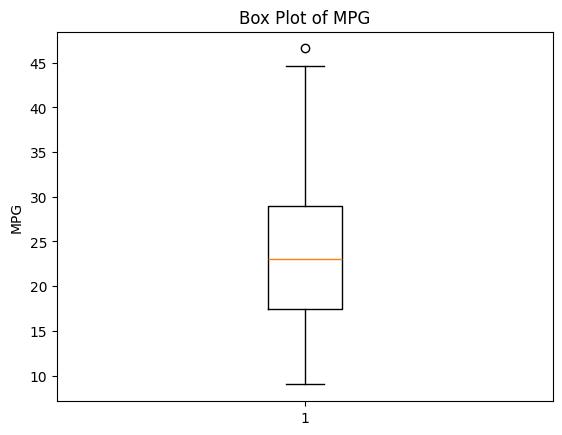

In [28]:
Q1 = df['mpg'].quantile(0.25)
Q2 = df['mpg'].quantile(0.50)  # Median
Q3 = df['mpg'].quantile(0.75)

IQR = Q3 - Q1

# Determine outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df['mpg'][(df['mpg'] < lower_bound) | (df['mpg'] > upper_bound)]

print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)
print("IQR:", IQR)
print("Number of Outliers:", len(outliers))

# Draw box plot
plt.figure()
plt.boxplot(df['mpg'])
plt.title("Box Plot of MPG")
plt.ylabel("MPG")
plt.show()